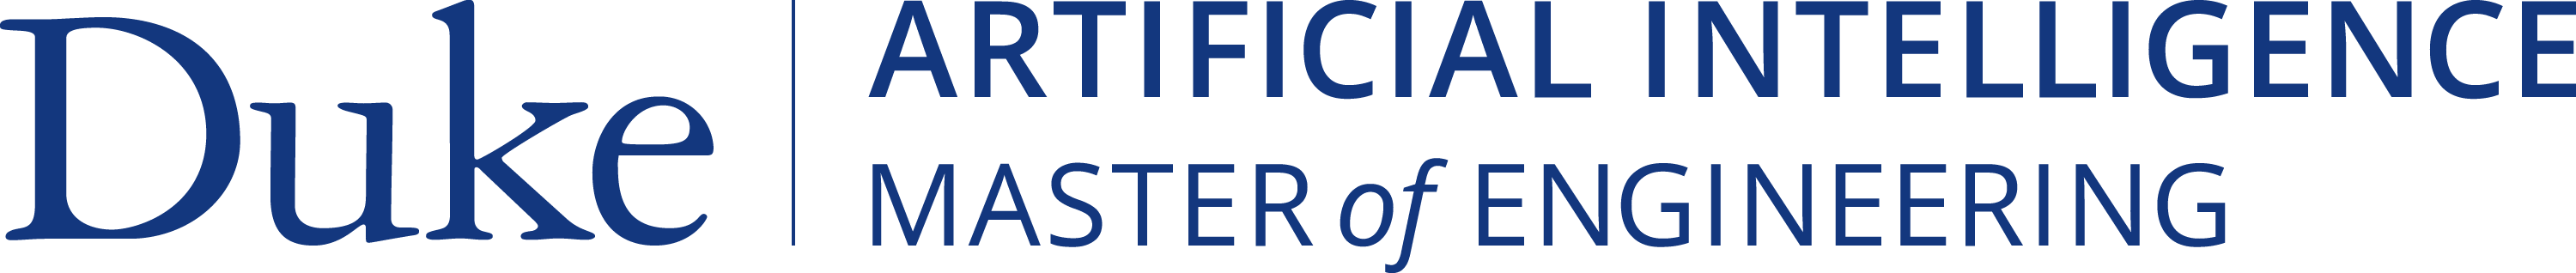


# AIPI 590 Applied Computer Vision
## Project 4 - Image Captioning
- Keese Phillips

# Attribution:
[Modern-Computer-Vision-with-PyTorch](https://github.com/PacktPublishing/Modern-Computer-Vision-with-PyTorch)

[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/keesephillips/applied_computer_vision_project_4/blob/main/model.ipynb)

In [ ]:
import os

# Remove Colab default sample_data
!rm -r ./sample_data

# Clone GitHub files to colab workspace
repo_name = "applied_computer_vision_project_4"
git_path = 'https://github.com/keesephillips/applied_computer_vision_project_4'
!git clone "{git_path}"

# Install dependencies from requirements.txt file
!pip install -r "{os.path.join(repo_name,'requirements.txt')}"

notebook_dir = ''
path_to_notebook = os.path.join(repo_name,notebook_dir)
%cd "{path_to_notebook}"
%ls

In [ ]:
import kagglehub
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.transforms as transforms
from collections import defaultdict
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from PIL import Image
from sklearn.model_selection import KFold
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset
from torchmetrics.text import BLEUScore
from torchsummary import summary
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torchvision import models
from torch_snippets import show
from torch_snippets.torch_loader import Report
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
path = kagglehub.dataset_download("adityajn105/flickr8k")

In [ ]:
data_dir = 'data'
os.makedirs(data_dir, exist_ok=True)

for item in os.listdir(path):
    s = os.path.join(path, item)
    d = os.path.join(data_dir, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)
    else:
        shutil.copy2(s, d)

In [4]:
data = pd.read_csv('data/captions.txt', sep=',', header=0)
data.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [5]:
tokenizer = get_tokenizer("basic_english")

def yield_tokens(data):
    for caption in data['caption']:
        yield tokenizer(caption.lower())

vocab = build_vocab_from_iterator(yield_tokens(data), specials=['<pad>', '<unk>', '<start>', '<end>'])
vocab.set_default_index(vocab['<unk>'])

all_captions = data['caption'].tolist()
all_tokens = [token for caption in all_captions for token in tokenizer(caption.lower())]

vocab.itos = ['<pad>'] + vocab.get_itos()[1:] 
vocab.stoi = defaultdict(lambda: vocab['<unk>'])
for i, token in enumerate(vocab.itos):
    vocab.stoi[token] = i

In [ ]:
np.random.seed(10)
data['train'] = np.random.choice([True,False], size=len(data), p=[0.90,0.10])
train_df = data[data['train']].copy().reset_index(drop=True)
val_df = data[~data['train']].copy().reset_index(drop=True)

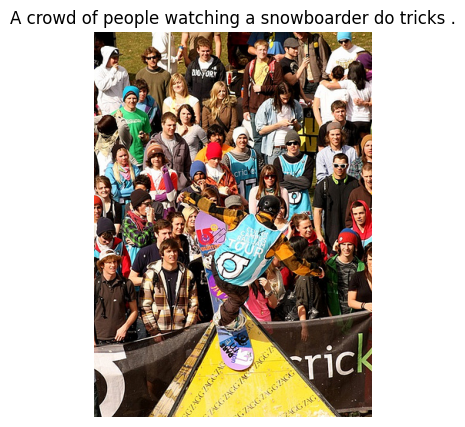

In [7]:
class CaptioningData(Dataset):
    def __init__(self, root, df, vocab):
        self.df = df.reset_index(drop=True)
        self.root = root
        self.vocab = vocab
        self.transform = transforms.Compose([
            transforms.Resize(224),
            transforms.RandomCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.485, 0.456, 0.406),
                                 (0.229, 0.224, 0.225))]
        )
    def __getitem__(self, index):
        """Returns one data pair (image and caption)."""
        row = self.df.iloc[index].squeeze()
        id = row.image
        image_path = f'{self.root}/{id}'
        image = Image.open(os.path.join(image_path)).convert('RGB')

        caption = row.caption
        tokens = str(caption).lower().split()
        target = []
        target.append(vocab.stoi['<start>'])
        target.extend([vocab.stoi[token] for token in tokens])
        target.append(vocab.stoi['<end>'])
        target = torch.Tensor(target).long()
        return image, target, caption
    def choose(self):
        return self[np.random.randint(len(self))]
    def __len__(self):
        return len(self.df)
    def collate_fn(self, data):
        data.sort(key=lambda x: len(x[1]), reverse=True)
        images, targets, captions = zip(*data)
        images = torch.stack([self.transform(image) for image in images], 0)
        lengths = [len(tar) for tar in targets]
        _targets = torch.zeros(len(captions), max(lengths)).long()
        for i, tar in enumerate(targets):
            end = lengths[i]
            _targets[i, :end] = tar[:end]
        return images.to(device), _targets.to(device), torch.tensor(lengths).long().to(device)

ds = CaptioningData('data/Images', data, vocab)
image, target, caption = ds.choose()
show(image, title=caption, sz=5)

In [8]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size, dropout_rate=0.1):
        """Load the pretrained ResNet-152 and replace top fc layer."""
        super(EncoderCNN, self).__init__()
        resnet = models.resnet152(pretrained=True)
        modules = list(resnet.children())[:-1] 
        self.resnet = nn.Sequential(*modules)
        self.linear = nn.Linear(resnet.fc.in_features, embed_size)
        self.bn = nn.BatchNorm1d(embed_size, momentum=0.01)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, images):
        """Extract feature vectors from input images."""
        with torch.no_grad():
            features = self.resnet(images)
        features = features.reshape(features.size(0), -1)
        features = self.bn(self.linear(features))
        features = self.dropout(features)
        return features

encoder = EncoderCNN(256).to(device)
print(summary(encoder, torch.zeros(32,3,224,224).to(device)))

Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /root/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth
100%|██████████| 230M/230M [00:03<00:00, 78.0MB/s]


Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 2048, 1, 1]          --
|    └─Conv2d: 2-1                       [-1, 64, 112, 112]        9,408
|    └─BatchNorm2d: 2-2                  [-1, 64, 112, 112]        128
|    └─ReLU: 2-3                         [-1, 64, 112, 112]        --
|    └─MaxPool2d: 2-4                    [-1, 64, 56, 56]          --
|    └─Sequential: 2-5                   [-1, 256, 56, 56]         --
|    |    └─Bottleneck: 3-1              [-1, 256, 56, 56]         75,008
|    |    └─Bottleneck: 3-2              [-1, 256, 56, 56]         70,400
|    |    └─Bottleneck: 3-3              [-1, 256, 56, 56]         70,400
|    └─Sequential: 2-6                   [-1, 512, 28, 28]         --
|    |    └─Bottleneck: 3-4              [-1, 512, 28, 28]         379,392
|    |    └─Bottleneck: 3-5              [-1, 512, 28, 28]         280,064
|    |    └─Bottleneck: 3-6              [-1, 512, 28, 28] 

In [ ]:
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers, dropout_rate=0.5, max_seq_length=80):
        """Set the hyper-parameters and build the layers."""
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout_rate)
        self.max_seq_length = max_seq_length

    def forward(self, features, captions, lengths):
        """Decode image feature vectors and generates captions."""
        embeddings = self.embed(captions)
        embeddings = self.dropout(embeddings)
        embeddings = torch.cat((features.unsqueeze(1), embeddings), 1)
        packed = pack_padded_sequence(embeddings, lengths.cpu(), batch_first=True)
        outputs, _ = self.lstm(packed)
        outputs = self.linear(outputs[0])
        return outputs

    def predict(self, features, states=None):
        """Generate captions for given image features using greedy search."""
        sampled_ids = []
        inputs = features.unsqueeze(1)
        for i in range(self.max_seq_length):
            hiddens, states = self.lstm(inputs, states) 
            outputs = self.linear(hiddens.squeeze(1)) 
            _, predicted = outputs.max(1) 
            sampled_ids.append(predicted)
            inputs = self.embed(predicted) 
            inputs = self.dropout(inputs)
            inputs = inputs.unsqueeze(1) 

        sampled_ids = torch.stack(sampled_ids, 1) 
        sentences = []
        for sampled_id in sampled_ids:
            sampled_id = sampled_id.cpu().numpy()
            sampled_caption = []
            for word_id in sampled_id:
                word = vocab.itos[word_id]
                sampled_caption.append(word)
                if word == '<end>':
                    break
            sentence = ' '.join(sampled_caption)
            sentences.append(sentence)
        return sentences

decoder = DecoderRNN(256, 512, len(vocab.itos), 5).to(device)

batch_size = 32
seq_length = 80
print(summary(decoder, [
    torch.zeros(batch_size, 256).to(device),
    torch.zeros(batch_size, seq_length).long().to(device),
    torch.full((batch_size,), seq_length).long().to(device) ]))


Layer (type:depth-idx)                   Output Shape              Param #
├─Embedding: 1-1                         [-1, 80, 256]             2,282,240
├─Dropout: 1-2                           [-1, 80, 256]             --
├─LSTM: 1-3                              [-1, 512]                 1,576,960
├─Linear: 1-4                            [-1, 8915]                4,573,395
Total params: 8,432,595
Trainable params: 8,432,595
Non-trainable params: 0
Total mult-adds (M): 8.42
Input size (MB): 0.04
Forward/backward pass size (MB): 0.23
Params size (MB): 32.17
Estimated Total Size (MB): 32.44
Layer (type:depth-idx)                   Output Shape              Param #
├─Embedding: 1-1                         [-1, 80, 256]             2,282,240
├─Dropout: 1-2                           [-1, 80, 256]             --
├─LSTM: 1-3                              [-1, 512]                 1,576,960
├─Linear: 1-4                            [-1, 8915]                4,573,395
Total params: 8,432,595
Train

In [10]:
def train_batch(data, encoder, decoder, optimizer, criterion):
    encoder.train()
    decoder.train()
    images, captions, lengths = data
    images = images.to(device)
    captions = captions.to(device)
    targets = pack_padded_sequence(captions, lengths.cpu(), batch_first=True)[0]
    features = encoder(images)
    outputs = decoder(features, captions, lengths)
    loss = criterion(outputs, targets)
    decoder.zero_grad()
    encoder.zero_grad()
    loss.backward()
    optimizer.step()
    return loss

In [11]:
@torch.no_grad()
def validate_batch(data, encoder, decoder, criterion):
    encoder.eval()
    decoder.eval()
    images, captions, lengths = data
    images = images.to(device)
    captions = captions.to(device)
    targets = pack_padded_sequence(captions, lengths.cpu(), batch_first=True)[0]
    features = encoder(images)
    outputs = decoder(features, captions, lengths)
    loss = criterion(outputs, targets)
    return loss

In [12]:
def initialize_models():
  encoder = EncoderCNN(256).to(device)
  decoder = DecoderRNN(256, 512, len(vocab.itos), 5).to(device)
  criterion = nn.CrossEntropyLoss()
  params = list(decoder.parameters()) + list(encoder.linear.parameters()) + list(encoder.bn.parameters())
  optimizer = torch.optim.AdamW(params, lr=1e-3)
  return encoder, decoder, criterion, optimizer, params

n_epochs = 10
batch_size = 64
n_folds = 3

EPOCH: 1.000  val_loss: 3.112  trn_loss: 3.733  (515.10s - 4635.86s remaining)
EPOCH: 2.000  val_loss: 2.833  trn_loss: 2.899  (1028.54s - 4114.16s remaining)
EPOCH: 3.000  val_loss: 2.697  trn_loss: 2.602  (1540.71s - 3594.99s remaining)
EPOCH: 4.000  val_loss: 2.622  trn_loss: 2.397  (2047.86s - 3071.79s remaining)
EPOCH: 5.000  val_loss: 2.584  trn_loss: 2.228  (2557.14s - 2557.14s remaining)
EPOCH: 6.000  val_loss: 2.553  trn_loss: 2.035  (3067.49s - 2044.99s remaining)
EPOCH: 7.000  val_loss: 2.552  trn_loss: 1.991  (3576.43s - 1532.75s remaining)
EPOCH: 8.000  val_loss: 2.554  trn_loss: 1.967  (4084.05s - 1021.01s remaining)
EPOCH: 9.000  val_loss: 2.553  trn_loss: 1.945  (4593.04s - 510.34s remaining)
EPOCH: 10.000  val_loss: 2.556  trn_loss: 1.921  (5099.78s - 0.00s remaining)
EPOCH: 1.000  val_loss: 3.116  trn_loss: 3.724  (5659.09s - 50931.80s remaining)
EPOCH: 2.000  val_loss: 2.868  trn_loss: 2.891  (6164.40s - 24657.60s remaining)
EPOCH: 3.000  val_loss: 2.728  trn_loss: 2

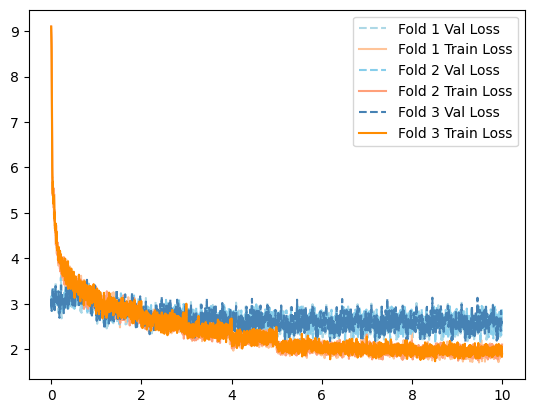

In [13]:
logs = [Report(n_epochs) for _ in range(n_folds)]

def get_dataloader(data, batch_size, shuffle=True):
    ds = CaptioningData('data/Images', data, vocab)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, collate_fn=ds.collate_fn)

kf = KFold(n_folds, shuffle=True)

best_val_loss = float('inf')
best_fold = -1
best_encoder = None
best_decoder = None

avg_trn_losses = []
avg_val_losses = []

for fold, (trn_idx, val_idx) in enumerate(kf.split(train_df.index)):
    trn_dl = get_dataloader(train_df.loc[trn_idx], batch_size)
    val_dl = get_dataloader(train_df.loc[val_idx], batch_size, shuffle=False)

    encoder, decoder, criterion, optimizer, params = initialize_models()

    trn_losses = []
    val_losses = []

    for epoch in range(n_epochs):
        if epoch == 5: optimizer = torch.optim.AdamW(params, lr=1e-4)
        N = len(trn_dl)
        trn_loss_epoch = 0
        for i, data in enumerate(trn_dl):
            trn_loss_batch = train_batch(data, encoder, decoder, optimizer, criterion)
            trn_loss_epoch += trn_loss_batch
            pos = epoch + (1+i)/N
            logs[fold].record(pos=pos, trn_loss=trn_loss_batch, end='\r')
        trn_loss_epoch /= N
        trn_losses.append(trn_loss_epoch)

        N = len(val_dl)
        val_loss_epoch = 0
        for i, data in enumerate(val_dl):
            val_loss_batch = validate_batch(data, encoder, decoder, criterion)
            val_loss_epoch += val_loss_batch
            pos = epoch + (1+i)/N
            logs[fold].record(pos=pos, val_loss=val_loss_batch, end='\r')
        val_loss_epoch /= N
        val_losses.append(val_loss_epoch)

        logs[fold].report_avgs(epoch+1)

    avg_trn_losses.append(sum(trn_losses) / len(trn_losses))
    avg_val_losses.append(sum(val_losses) / len(val_losses))

    if avg_val_losses[-1] < best_val_loss:
        best_val_loss = avg_val_losses[-1]
        best_fold = fold
        best_encoder = encoder
        best_decoder = decoder

        torch.save(best_encoder.state_dict(), "/content/drive/MyDrive/best_encoder.pth")
        torch.save(best_decoder.state_dict(), "/content/drive/MyDrive/best_decoder.pth")

graph_colors = [
    '#ADD8E6',  # Light Blue
    '#FFC499',  # Pastel Orange
    '#87CEEB',  # Sky Blue
    '#FFA07A',  # Light Orange
    '#4682B4',  # Steel Blue
    '#FF8C00',  # Orange
    '#2F4F7F',  # Dark Blue
    '#FF6600',  # Dark Orange
    '#1A1D23'   # Navy Blue
    '#FF4500'   # Burnt Orange
]
color_index = 0
for fold in range(n_folds):
  plt.plot(np.arange(0,n_epochs,(n_epochs/len(logs[fold].history('val_loss')))),
          logs[fold].history('val_loss'),
          label=f'Fold {fold+1} Val Loss',
          linestyle='--',
          color=graph_colors[color_index]
          )
  plt.plot(np.arange(0,n_epochs,(n_epochs/len(logs[fold].history('trn_loss')))),
          logs[fold].history('trn_loss'),
          label=f'Fold {fold+1} Train Loss',
          color=graph_colors[color_index+1]
  )
  color_index += 2

plt.legend()
plt.show()

In [ ]:
def calculate_bleu_score(encoder, decoder, val_ds, device, vocab, batch_size):
    encoder.eval()
    decoder.eval()

    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=val_ds.collate_fn)

    all_predictions = []
    all_references = []

    with torch.no_grad():
        for images, _, lengths in tqdm(val_loader, desc="Calculating BLEU score"):
            features = encoder(images)
            sampled_ids = decoder.predict(features)

            for sample in sampled_ids:
                prediction = []

                all_predictions.append(' '.join(pred if pred not in ['<start>','<end>','<pad>'] else '' for pred in sample.split()))

            for i in range(images.size(0)):
                reference = val_ds.df.iloc[i]['caption']
                all_references.append([reference.split()])

    bleu_score = 0
    smoothing_function = SmoothingFunction().method4
    for i in range(len(all_predictions)):
        prediction = all_predictions[i].split()
        reference = all_references[i][0]
        bleu_score += sentence_bleu(reference, prediction, smoothing_function=smoothing_function, weights=[1])
    bleu_score /= len(all_predictions)
    return bleu_score

val_ds = CaptioningData('data/Images', val_df, vocab)
bleu_score = calculate_bleu_score(encoder, decoder, val_ds, device, vocab, batch_size)
print(f"BLEU-1 Score on validation set: {bleu_score:.4f}")

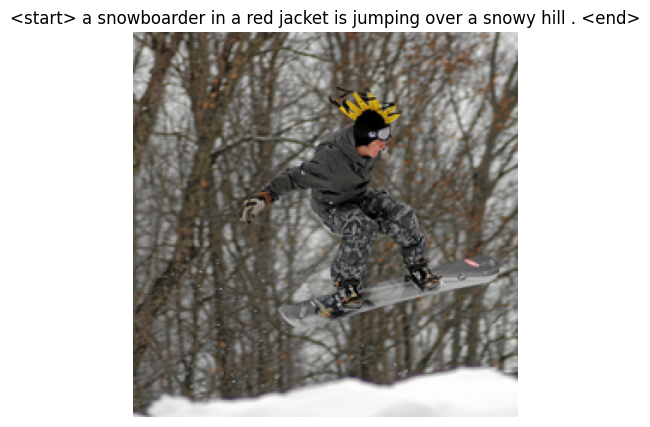

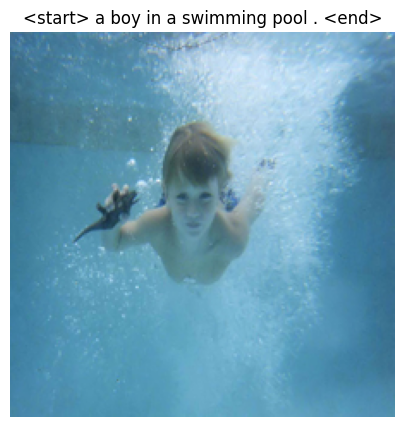

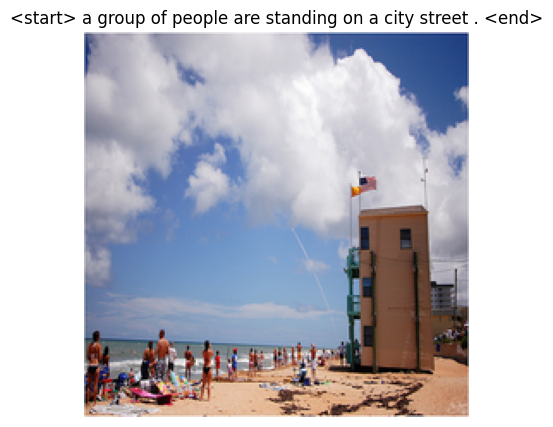

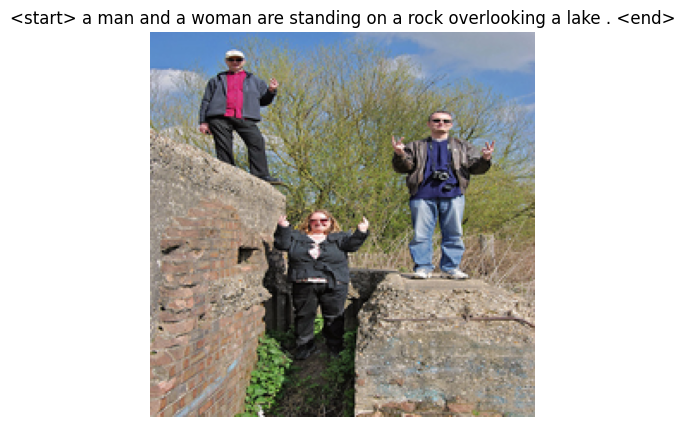

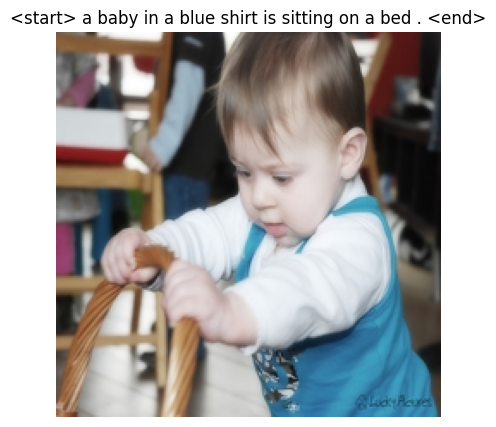

In [18]:
def load_image(image_path, transform=None):
    image = Image.open(image_path).convert('RGB')
    image = image.resize([224, 224], Image.LANCZOS)
    if transform is not None:
        tfm_image = transform(image)[None]
    return image, tfm_image

@torch.no_grad()
def load_image_and_predict(image_path):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406),
                             (0.229, 0.224, 0.225))
    ])

    org_image, tfm_image = load_image(image_path, transform)
    image_tensor = tfm_image.to(device)
    encoder.eval()
    decoder.eval()
    feature = encoder(image_tensor)
    sentence = decoder.predict(feature)[0]
    show(org_image, title=sentence)
    return sentence


def choose(items):
    return np.random.choice(items)

# files = glob.glob('val-images/*')
files = val_df['image'].apply(lambda x: 'data/Images/' + x).tolist()
for _ in range(5):
    load_image_and_predict(choose(files))


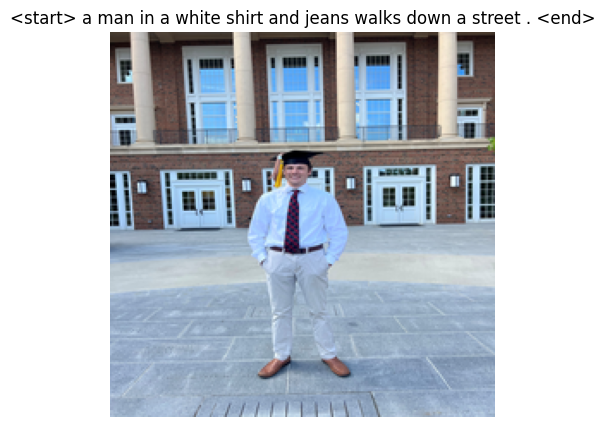

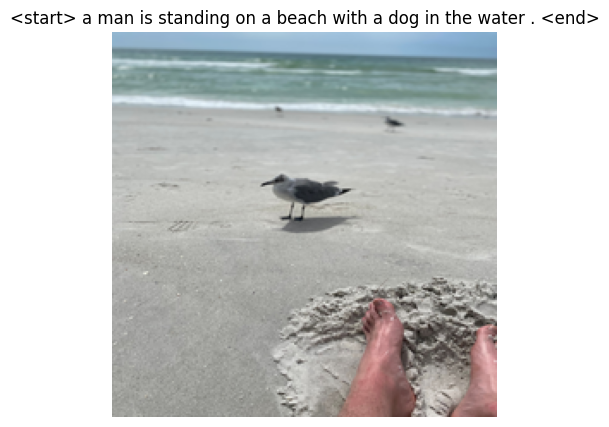

In [32]:
files = ['assets/grad.jpg','assets/bird.jpg']
for file in files:
    load_image_and_predict(file)